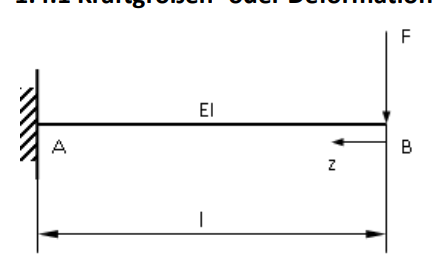

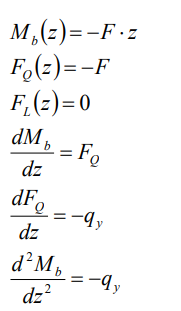

In [1]:
import sympy as sp

# Symbole
z   = sp.symbols('z', real=True)   # Ort entlang des Bauteils
F   = sp.symbols('F', real=True)   # resultierende Kraft
qy  = sp.symbols('q_y', real=True) # Linienlast

# Grund-Relationen (aus deinen Gleichungen)
M_b = -F * z      # M_b(z) = -F · z
F_Q = -F          # F_Q(z) = -F   (konstant)
F_L = 0           # F_L(z) = 0    (keine Längskraft)

# Ableitungen (Kontinuitätsbeziehungen)
dMb_dz      = sp.diff(M_b, z)      # dM_b/dz
dFQ_dz      = sp.diff(F_Q, z)      # dF_Q/dz
d2Mb_dz2    = sp.diff(M_b, z, 2)   # d²M_b/dz²

M_b, F_Q, F_L, dMb_dz, dFQ_dz, d2Mb_dz2

(-F*z, -F, 0, -F, 0, 0)

Beschreibung einer Linearen Verschiebung

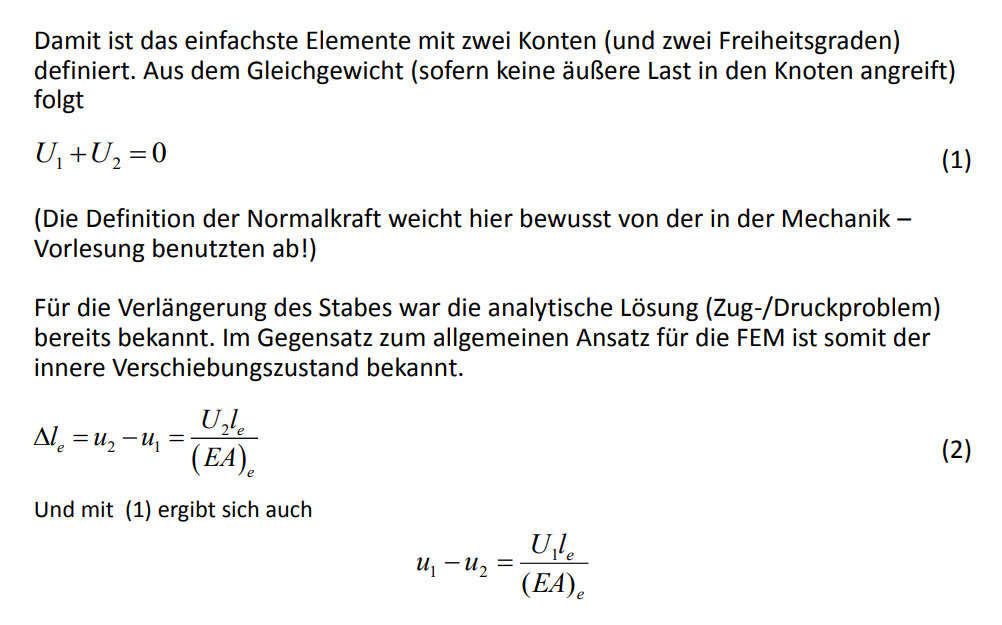

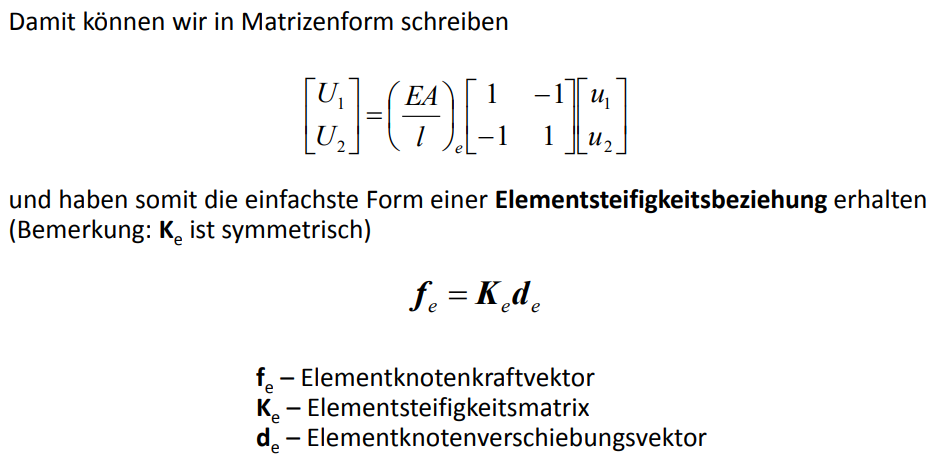

Grundlagen: Rechnen mit Matrizen in Python: 

In [20]:
import numpy as np
A = np.array([[1, 2],
              [3, 4]])    # 2x2-Matrix
b = np.array([5, 6])      # Vektor

# Transponieren
A_T = A.T

# Matrix + Matrix
C = A + A

# Skalar * Matrix
D = 2 * A

E = A@b
E

array([17, 39])

In [24]:
%reset


Umsetzten der gezeigten Matrize:

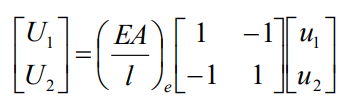

In [26]:
import sympy as sp

In [27]:
# So kann man gleichen mehrere Variablen gleichzeitig erzeugen.
U  = sp.symbols('U_1:3', real=True) 
# Hier sind es U_1 und U_2

In [28]:
# Und so mache ich das direkt zu einen Vektor
U = sp.Matrix(sp.symbols("U_1:3", real = True))
U

Matrix([
[U_1],
[U_2]])

In [29]:
u = sp.Matrix(sp.symbols("u_1:3", real=True))
u

Matrix([
[u_1],
[u_2]])

In [30]:
E = sp.symbols("E", real = True)
A = sp.symbols("A", rela = True)
l = sp.symbols("l", reals = True)

In [31]:
K = (E*A / l )*sp.Matrix([[1,-1], [-1, 1]])
K

Matrix([
[ A*E/l, -A*E/l],
[-A*E/l,  A*E/l]])

In [32]:
e1 = sp.Eq(U, K@u)
e1

Eq(Matrix([
[U_1],
[U_2]]), Matrix([
[ A*E*u_1/l - A*E*u_2/l],
[-A*E*u_1/l + A*E*u_2/l]]))

In [33]:
%reset -f

Erstellen dieser Matrix:


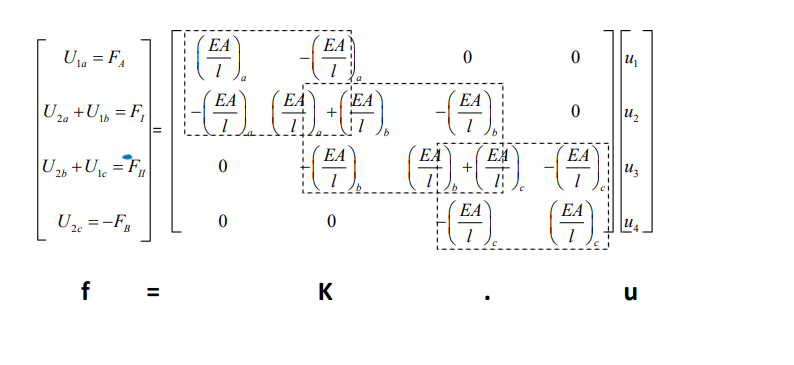

In [35]:
import numpy as np
import sympy as sp

In [ ]:
# Wie ich mir das denke: 
lines = []
for i in range(4):
    line = np.zeros(4)
    line[i]  = 1
    try:
        line[i-1] = -1
    except:
        pass
    try:
        line[i+1] = -1
    except:
        pass
    lines.append(line)
K = sp.Matrix(lines)
K

Matrix([
[ 1.0, -1.0,  0.0, -1.0],
[-1.0,  1.0, -1.0,  0.0],
[ 0.0, -1.0,  1.0, -1.0],
[ 0.0,  0.0, -1.0,  1.0]])

In [41]:
# Was ChatGPT meint wie man das macht. 
n = 4

# NumPy: erst die drei Diagonalen bauen
K_np = (np.diag(np.ones(n))                # Hauptdiagonale: 1
        + np.diag(-np.ones(n-1),  1)       # obere Nebendiagonale: -1
        + np.diag(-np.ones(n-1), -1))      # untere Nebendiagonale: -1

# zusätzlich die "Eckkopplung" wie in deinem Code (row 0, col n-1)
K_np[0, -1] = -1

# in SymPy-Matrix umwandeln
K = sp.Matrix(K_np)
K

Matrix([
[ 1.0, -1.0,  0.0, -1.0],
[-1.0,  1.0, -1.0,  0.0],
[ 0.0, -1.0,  1.0, -1.0],
[ 0.0,  0.0, -1.0,  1.0]])

In [43]:
A_a, A_b, A_c = sp.symbols('A_a A_b A_c')   # Querschnitte
E_a, E_b, E_c = sp.symbols('E_a E_b E_c')   # Elastizitätsmodule
l_a, l_b, l_c = sp.symbols('l_a l_b l_c')   # Längen

A = sp.Matrix([A_a, A_b, A_c])              # A-Vektor
E = sp.Matrix([E_a, E_b, E_c])              # E-Vektor
L = sp.Matrix([l_a, l_b, l_c])              # l-Vektor

k = sp.Matrix([
    E_a*A_a/l_a,
    E_b*A_b/l_b,
    E_c*A_c/l_c,
]) 

In [ ]:
# Um die Konstanten aus der Konstantenmatrix k den richtigen Zellen in der 
# Matrix K zuordenen zu können brauche ich nun eine Indexmatrix. 

B = sp.Matrix([
    [ 1, -1,  0,  0],
    [ 0,  1, -1,  0],
    [ 0,  0,  1, -1],
])

# 1 ist immer das rechte Ende des Knoten
# -1 ist immer das linke Ende des Knoten




In [47]:
K = B.T * sp.diag(*k) * B
K

Matrix([
[ A_a*E_a/l_a,              -A_a*E_a/l_a,                         0,            0],
[-A_a*E_a/l_a, A_a*E_a/l_a + A_b*E_b/l_b,              -A_b*E_b/l_b,            0],
[           0,              -A_b*E_b/l_b, A_b*E_b/l_b + A_c*E_c/l_c, -A_c*E_c/l_c],
[           0,                         0,              -A_c*E_c/l_c,  A_c*E_c/l_c]])

In [50]:
U = sp.Matrix(sp.symbols("U_1:5", real = True))
u = sp.Matrix(sp.symbols("u_1:5", real=True))

In [51]:
eq = sp.Eq(U, K@u)
eq

Eq(Matrix([
[U_1],
[U_2],
[U_3],
[U_4]]), Matrix([
[                                   A_a*E_a*u_1/l_a - A_a*E_a*u_2/l_a],
[-A_a*E_a*u_1/l_a - A_b*E_b*u_3/l_b + u_2*(A_a*E_a/l_a + A_b*E_b/l_b)],
[-A_b*E_b*u_2/l_b - A_c*E_c*u_4/l_c + u_3*(A_b*E_b/l_b + A_c*E_c/l_c)],
[                                  -A_c*E_c*u_3/l_c + A_c*E_c*u_4/l_c]]))

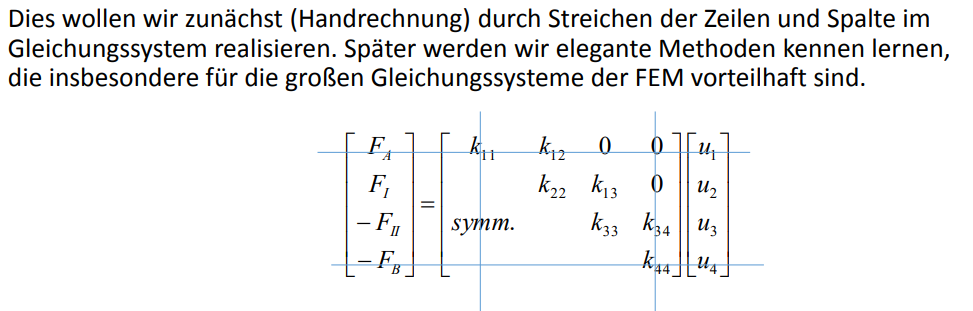